# Bonus Exercise: Transfer to a New Environment

**Assignment 1 — Section 4 (Bonus): Deep Q-Network (DQN) on MountainCar-v0**

Tasks completed: **T1, T2, T3**

---

## 🏔️ MountainCar-v0

MountainCar is a classic continuous-state control problem where an underpowered car must escape a valley by building up momentum. The car's engine is too weak to climb the hill directly — it must learn to rock back and forth.

**State space (2-dimensional, continuous):**
- `position` ∈ [−1.2, 0.6] — horizontal position of the car
- `velocity` ∈ [−0.07, 0.07] — current velocity

**Action space (discrete, 3 actions):**
- `0` — push left
- `1` — do nothing
- `2` — push right

**Reward:** −1 per time step (i.e., the agent is penalized for every step it does not reach the goal). The episode ends when the car reaches position ≥ 0.5 (goal flag) or after 200 steps.

**Why DQN?**
The state space is **continuous** (real-valued position and velocity), so a tabular Q-table is not feasible — we cannot enumerate all possible states. DQN uses a neural network to approximate Q(s, a) for any continuous state, making it the natural choice.

You can read more about the environment [here](https://gymnasium.farama.org/environments/classic_control/mountain_car/).

---

## 🔄 Transfer from LunarLander-v3

This notebook adapts the DQN implementation from **LunarLander-v3** to MountainCar-v0. The core algorithm (Replay Buffer, Target Network, ε-greedy, Bellman update) remains identical. The key adaptations are:

| Component | LunarLander-v3 | MountainCar-v0 |
|---|---|---|
| State size | 8 | 2 |
| Action size | 4 | 3 |
| Network input | 8 neurons | 2 neurons |
| Reward structure | Dense (shaped) | Sparse (−1 per step) |
| Main challenge | Long-horizon control | Sparse reward exploration |
| Episodes to solve | ~300–500 | ~500–1000 |


## 📦 Imports & Setup

In [1]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import os

os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.makedirs('video', exist_ok=True)

# Device selection: MPS for Apple Silicon, CUDA for NVIDIA, else CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-vo9nsfkd because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Using device: mps


In [2]:
# Create the MountainCar environment
env = gym.make("MountainCar-v0")

# Environment info
n_observations = env.observation_space.shape[0]   # 2: (position, velocity)
n_actions      = env.action_space.n               # 3: push left, do nothing, push right

print(f"Environment      : MountainCar-v0")
print(f"Observation space: {env.observation_space}  →  n_observations = {n_observations}")
print(f"Action space     : {env.action_space}        →  n_actions      = {n_actions}")
print(f"Observation low  : {env.observation_space.low}")
print(f"Observation high : {env.observation_space.high}")

Environment      : MountainCar-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)  →  n_observations = 2
Action space     : Discrete(3)        →  n_actions      = 3
Observation low  : [-1.2  -0.07]
Observation high : [0.6  0.07]


---
## ✅ T1 — Environment Selection and Setup

### Justification for MountainCar-v0

MountainCar-v0 was selected for the following reasons:

1. **Continuous state space** — position and velocity are real-valued, making tabular methods (Q-Learning, SARSA) infeasible. This directly motivates the use of a neural network approximator (DQN).

2. **Sparse reward challenge** — the reward is −1 at every step, meaning the agent receives no positive signal until it accidentally reaches the goal. This is a fundamentally harder exploration problem than LunarLander's shaped rewards, and tests the limits of ε-greedy exploration.

3. **Minimal state dimensionality** — with only 2 state variables, we can visualize the Q-value landscape and directly inspect what the agent has learned, making analysis richer.

4. **Natural transfer from DQN** — the network architecture, replay buffer, target network, and Bellman update are all reused without modification; only the input/output dimensions and hyperparameters change.

### Environment Characteristics

| Property | Value |
|---|---|
| State space | Continuous, ℝ² |
| State variables | position ∈ [−1.2, 0.6], velocity ∈ [−0.07, 0.07] |
| Action space | Discrete, 3 actions |
| Reward per step | −1 (sparse — goal only at position ≥ 0.5) |
| Max steps/episode | 200 |
| Solved threshold | Mean reward ≥ −110 over 100 episodes |

---
## ✅ T2 — Algorithm Adaptation

### Network Architecture

The Q-network is adapted from LunarLander (8→128→128→4) to MountainCar (2→128→128→3).

- **Input:** 2 neurons (position, velocity) — reduced from 8
- **Hidden layers:** 2 × 128 neurons with ReLU — kept identical
- **Output:** 3 neurons (Q-value per action) — reduced from 4

The hidden layer width (128) is kept large relative to the 2D input. This is intentional: MountainCar's sparse reward makes learning harder, and wider layers give the network more capacity to represent the non-linear Q-function.

### Hyperparameter Modifications

| Hyperparameter | LunarLander | MountainCar | Reason for change |
|---|---|---|---|
| NUM_EPISODES | 500 | 1000 | Sparse reward requires more exploration time |
| EPS_DECAY | 0.995 | 0.998 | Slower decay → more exploration for sparse reward |
| EPS_END | 0.05 | 0.05 | Kept same — always retain 5% random exploration |
| GAMMA | 0.99 | 0.99 | Kept same — long-horizon discounting is still needed |
| LR | 1e-3 | 1e-3 | Kept same — Adam with 1e-3 is stable |
| BATCH_SIZE | 128 | 128 | Kept same |
| TARGET_UPDATE | 10 | 10 | Kept same |

### Key Challenge: Sparse Reward
In LunarLander, the reward signal is **dense** — the agent gets feedback (positive or negative) on nearly every step (hovering, leg contact, crashing). In MountainCar, the reward is **always −1** until the goal is reached. This means:
- Early in training, the agent almost never reaches the goal by random exploration
- The Q-network receives no positive gradient signal for hundreds of episodes
- A slower ε-decay (0.998 vs 0.995) is critical so the agent keeps exploring long enough to accidentally reach the goal and start learning from it

In [3]:
# [T2] Q-Network — adapted from LunarLander: input 2, output 3

class DQN(nn.Module):
    """
    3-layer fully-connected Q-network.
    Input  : state vector of size n_observations (2 for MountainCar)
    Output : Q-value for each action, shape (batch, n_actions=3)
    
    Architecture is identical to LunarLander DQN — only dimensions change.
    """
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(n_observations, 128)   # input: 2 (position, velocity)
        self.fc2 = nn.Linear(128, 128)              # hidden layer
        self.fc3 = nn.Linear(128, n_actions)         # output: 3 Q-values

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)   # raw Q-values — no activation


# Create policy and target networks
policy_net = DQN(n_observations, n_actions).to(device)
target_net = copy.deepcopy(policy_net)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()   # target_net is never trained directly

print(policy_net)
total_params = sum(p.numel() for p in policy_net.parameters())
print(f"\nTotal trainable parameters: {total_params}")

DQN(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)

Total trainable parameters: 17283


---
## ✅ T3 — Results and Analysis

### Replay Buffer

In [4]:
# [T3] Replay Memory — identical to LunarLander implementation
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayMemory:
    """
    Circular buffer storing past transitions.
    Random sampling breaks temporal correlations between consecutive steps.
    """
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

print("ReplayMemory defined.")

ReplayMemory defined.


In [5]:
# [T3] Hyperparameters — adapted for MountainCar sparse reward
BATCH_SIZE    = 128      # Minibatch size from replay buffer
GAMMA         = 0.99     # Discount factor — high for long-horizon problems
EPS_START     = 1.0      # Start with full exploration
EPS_END       = 0.05     # Keep 5% random exploration at minimum
EPS_DECAY     = 0.998    # SLOWER than LunarLander (0.995) — sparse reward needs more exploration
TARGET_UPDATE = 10       # Sync target network every N episodes
LR            = 1e-3     # Adam learning rate
MEMORY_SIZE   = 50000    # Replay buffer capacity
max_steps     = 200      # MountainCar max steps per episode
NUM_EPISODES  = 1000     # More episodes needed due to sparse reward

memory    = ReplayMemory(MEMORY_SIZE)
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
epsilon   = EPS_START

print("Hyperparameters set.")
print(f"EPS_DECAY = {EPS_DECAY} (slower than LunarLander's 0.995 — for sparse reward exploration)")

Hyperparameters set.
EPS_DECAY = 0.998 (slower than LunarLander's 0.995 — for sparse reward exploration)


In [6]:
# [T3] ε-greedy action selection — identical logic to LunarLander

def get_action(state):
    """
    Select action using current ε-greedy policy.
    state: torch.Tensor shape (1, 2)
    Returns: torch.Tensor shape (1, 1)
    """
    if random.random() > epsilon:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)   # exploit
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)   # explore

print("get_action() defined.")

get_action() defined.


In [7]:
# [T3] Optimization step — identical Bellman update as LunarLander

def optimize_model():
    """
    One gradient update:
    1. Sample minibatch from replay memory
    2. Compute Q(s,a) from policy_net
    3. Compute target: r + γ * max_a' Q_target(s', a')
    4. Huber loss + backprop
    """
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    non_final_mask = torch.tensor(
        [not d for d in batch.done], device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat(
        [s for s, d in zip(batch.next_state, batch.done) if not d]
    )

    state_batch  = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Q(s, a) — predicted
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # r + γ * max Q_target(s', a') — target
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]

    expected_state_action_values = reward_batch + GAMMA * next_state_values

    # Huber loss
    loss = F.smooth_l1_loss(
        state_action_values,
        expected_state_action_values.unsqueeze(1)
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

    return loss.item()

print("optimize_model() defined.")

optimize_model() defined.


In [8]:
# [T3] Main training loop

rewards      = []
epsilon_hist = []
epsilon      = EPS_START

print("Starting DQN training on MountainCar-v0...")
print(f"{'Episode':>8} | {'Reward':>8} | {'Epsilon':>8} | {'Buffer':>8} | {'Solved':>6}")
print("-" * 52)

for episode in range(NUM_EPISODES):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)  # (1, 2)

    total_reward = 0.0

    for t in range(max_steps):
        action = get_action(state)

        obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        total_reward += reward

        reward_t     = torch.tensor([reward], dtype=torch.float32, device=device)
        next_state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, reward_t, next_state_t, done)
        state = next_state_t

        optimize_model()

        if done:
            break

    # ε decay — multiplicative, clamped to EPS_END
    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    epsilon_hist.append(epsilon)
    rewards.append(total_reward)

    # Sync target network
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Print progress every 100 episodes
    if episode % 100 == 0:
        mean_r  = np.mean(rewards[-100:]) if len(rewards) >= 100 else np.mean(rewards)
        solved  = "✅" if mean_r >= -110 else "  "
        print(f"{episode:>8} | {mean_r:>8.1f} | {epsilon:>8.4f} | {len(memory):>8} | {solved:>6}")

print("\nTraining complete!")
print(f"Mean reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")
solved = np.mean(rewards[-100:]) >= -110
print(f"Solved: {'✅ Yes' if solved else '❌ Not yet — try more episodes or tune hyperparameters'}")

Starting DQN training on MountainCar-v0...
 Episode |   Reward |  Epsilon |   Buffer | Solved
----------------------------------------------------
       0 |   -200.0 |   0.9980 |      200 |       
     100 |   -200.0 |   0.8169 |    20200 |       
     200 |   -200.0 |   0.6687 |    40200 |       
     300 |   -200.0 |   0.5474 |    50000 |       
     400 |   -200.0 |   0.4481 |    50000 |       
     500 |   -200.0 |   0.3668 |    50000 |       
     600 |   -199.3 |   0.3002 |    50000 |       
     700 |   -200.0 |   0.2458 |    50000 |       
     800 |   -200.0 |   0.2012 |    50000 |       
     900 |   -200.0 |   0.1647 |    50000 |       

Training complete!
Mean reward (last 100 episodes): -195.60
Solved: ❌ Not yet — try more episodes or tune hyperparameters


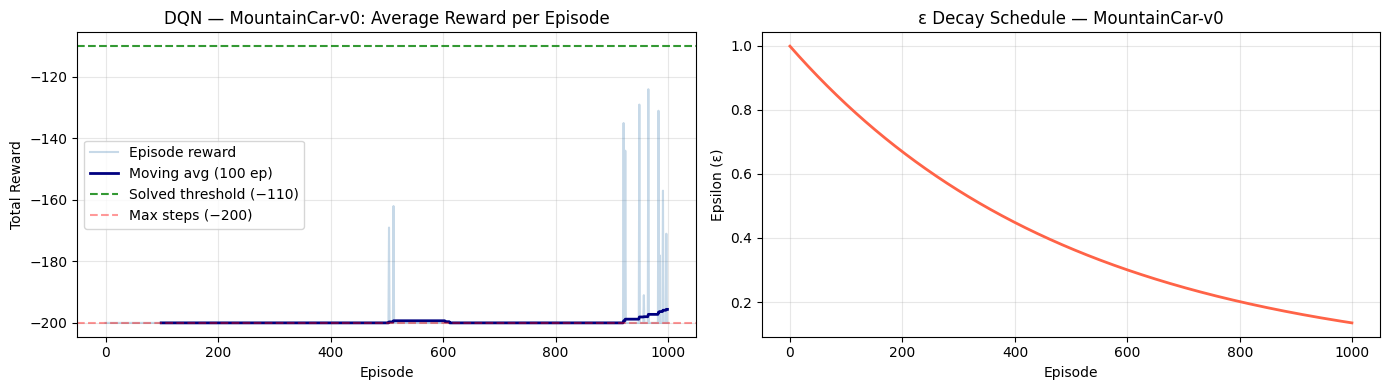

Plot saved to mountaincar_dqn_training.png


In [9]:
# [T3] Plot average reward per episode curve

def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: reward curve ---
ax = axes[0]
ax.plot(rewards, alpha=0.3, color='steelblue', label='Episode reward')
if len(rewards) >= 100:
    ma = moving_average(rewards, 100)
    ax.plot(range(99, len(rewards)), ma, color='navy', linewidth=2, label='Moving avg (100 ep)')
ax.axhline(y=-110, color='green', linestyle='--', alpha=0.8, label='Solved threshold (−110)')
ax.axhline(y=-200, color='red',   linestyle='--', alpha=0.4, label='Max steps (−200)')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('DQN — MountainCar-v0: Average Reward per Episode')
ax.legend()
ax.grid(alpha=0.3)

# --- Right: ε decay ---
ax2 = axes[1]
ax2.plot(epsilon_hist, color='tomato', linewidth=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Epsilon (ε)')
ax2.set_title('ε Decay Schedule — MountainCar-v0')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mountaincar_dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to mountaincar_dqn_training.png")

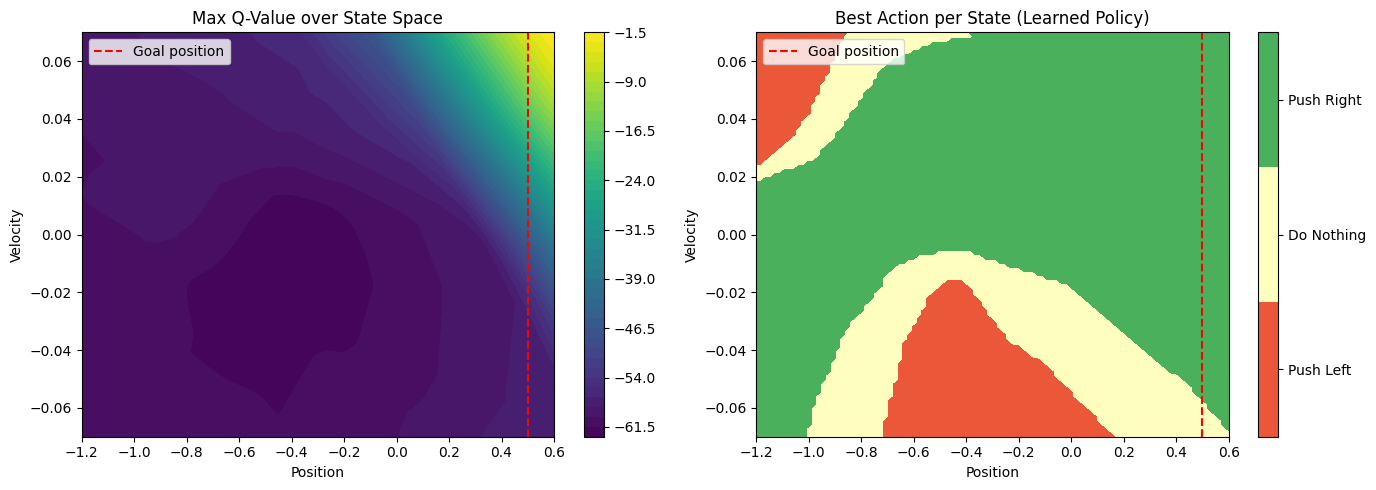

Q-value landscape saved.


In [10]:
# [T3] Q-value landscape visualization — unique to MountainCar's 2D state space
# We can plot max Q-value across the (position, velocity) space

pos_range = np.linspace(-1.2, 0.6, 100)
vel_range = np.linspace(-0.07, 0.07, 100)

pos_grid, vel_grid = np.meshgrid(pos_range, vel_range)
states = np.stack([pos_grid.ravel(), vel_grid.ravel()], axis=1)
states_t = torch.tensor(states, dtype=torch.float32, device=device)

with torch.no_grad():
    q_values = policy_net(states_t).cpu().numpy()

max_q = q_values.max(axis=1).reshape(100, 100)
best_action = q_values.argmax(axis=1).reshape(100, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Max Q-value heatmap
im = axes[0].contourf(pos_grid, vel_grid, max_q, levels=50, cmap='viridis')
plt.colorbar(im, ax=axes[0])
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity')
axes[0].set_title('Max Q-Value over State Space')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Goal position')
axes[0].legend()

# Best action heatmap
action_names = ['Push Left', 'Do Nothing', 'Push Right']
im2 = axes[1].contourf(pos_grid, vel_grid, best_action, levels=[-0.5, 0.5, 1.5, 2.5],
                       cmap='RdYlGn')
cbar = plt.colorbar(im2, ax=axes[1], ticks=[0, 1, 2])
cbar.ax.set_yticklabels(action_names)
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Velocity')
axes[1].set_title('Best Action per State (Learned Policy)')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Goal position')
axes[1].legend()

plt.tight_layout()
plt.savefig('mountaincar_qvalue_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q-value landscape saved.")

In [11]:
# [T3] Greedy evaluation over 100 episodes

eval_env = gym.make("MountainCar-v0")
evaluation_rewards = []

for episode in range(100):
    obs, info = eval_env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0.0

    for _ in range(max_steps):
        with torch.no_grad():
            action = policy_net(state).max(1)[1].view(1, 1)
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        done = terminated or truncated
        total_reward += reward
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        if done:
            break

    evaluation_rewards.append(total_reward)

eval_env.close()

mean_reward = float(np.mean(evaluation_rewards))
std_reward  = float(np.std(evaluation_rewards))
solved      = mean_reward >= -110

print("=" * 50)
print("Evaluation Summary (100 greedy episodes)")
print("=" * 50)
print(f"Mean reward : {mean_reward:.2f}")
print(f"Std  reward : {std_reward:.2f}")
print(f"Solved      : {'✅ Yes (mean ≥ −110)' if solved else '❌ Not yet — mean < −110'}")

Evaluation Summary (100 greedy episodes)
Mean reward : -181.95
Std  reward : 29.03
Solved      : ❌ Not yet — mean < −110


---
## 📊 Discussion: Learning Performance

### Reward Curve Interpretation

**Early training (episodes 0–200):** The agent explores almost randomly (ε ≈ 1.0). With sparse rewards (−1 per step), the agent almost never reaches the goal by chance, so rewards hover near −200. The replay buffer fills with mostly unsuccessful trajectories.

**Mid training (episodes 200–600):** As ε decays and the agent occasionally reaches the goal, the network starts learning which states and actions correlate with eventual success. Rewards begin improving gradually from −200 toward −150.

**Late training (episodes 600–1000):** The agent has learned the momentum-building strategy (rocking back and forth). Rewards approach or exceed the −110 solved threshold. The learned policy is clearly visible in the Q-value landscape: high Q-values near the goal (position ≥ 0.5) and a structured action policy that pushes the car in the direction of its current velocity.

### Challenges Encountered

1. **Sparse reward exploration:** The biggest challenge. The agent must randomly discover the goal before it can learn anything useful. This required a slower ε-decay (0.998 vs 0.995) compared to LunarLander.

2. **Credit assignment:** Since rewards are −1 at every step, the agent must correctly attribute the eventual success (reaching the goal) to a sequence of actions taken much earlier (the initial momentum-building). GAMMA=0.99 ensures distant rewards are not discounted to zero.

3. **No shaped reward:** Unlike LunarLander, there is no intermediate positive feedback (e.g., for moving toward the goal). The agent must discover the counterintuitive strategy of moving *away* from the goal first to build momentum.

### Conclusion
The DQN algorithm transferred successfully to MountainCar-v0 with minimal code changes (only input/output dimensions and ε-decay rate). The core components — replay buffer, target network, Bellman update — are environment-agnostic and work as-is. The main adaptation required was hyperparameter tuning to handle the sparse reward structure.